In [4]:
import sys
sys.path.insert(0, '../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json
from copy import deepcopy

from farmers_intermediaries import Instance
from road_graphs import RoadGraph
import pickle
import pandas as pd
import pricing
from pricing import Optimizer
from datetime import datetime, timedelta
import numpy as np


json_files = {}
directory = "../data/results_scaling_ints"

for filename in os.listdir(directory):
    if filename.endswith(".json"):
        filepath = os.path.join(directory, filename)
        with open(filepath, 'r') as file:
            json_files[filename] = json.load(file)

TypeError: string indices must be integers, not 'str'

In [12]:
gap_dict = []
for name, result in json_files.items():
    gap_dict.append({
        "vanilla_profit": result["summary_vanilla"]["max_int_welf_sol"]["profit"]/14500.0,
        "structured_profit": result["summary_structured"]["max_int_welf_sol"]["profit"]/14500.0,
        "domination_profit": result["summary_domination"]["max_int_welf_sol"]["profit"]/14500.0,
        "suboptimal_profit": result["summary_vanilla"]["forced_lower_bound"]/14500.0,
        "time_vanilla": result["summary_vanilla"]["total_time"],
        "time_structured": result["summary_structured"]["total_time"],
        "time_domination": result["summary_domination"]["total_time"],
        "time_suboptimal": result["summary_vanilla"]["timestamps"][0],
        "avg_epsilon": result["epsilon"],
        'fruit_value': np.sum(list(result["farmer_quantities"].values())) * (2513.0 * 1000.0)/14500.0,
        'profit_percentage': result["summary_vanilla"]["max_int_welf_sol"]["profit"] / (np.sum(list(result["farmer_quantities"].values())) * 2513.0 * 1000.0),
        "instance": result["instance_id"],
        'max_welfare_farmers': result["summary_vanilla"]["min_int_welf_sol"]["farmer_welfare"] / (np.sum(list(result["farmer_quantities"].values())) * 2513.0 * 1000.0),
        'min_welfare_farmers': result["summary_vanilla"]["max_int_welf_sol"]["farmer_welfare"] / (np.sum(list(result["farmer_quantities"].values())) * 2513.0 * 1000.0),
        'max_welfare_intermediaries': result["summary_vanilla"]["max_int_welf_sol"]["intermediary_welfare"] / (np.sum(list(result["farmer_quantities"].values())) * 2513.0 * 1000.0),
        'min_welfare_intermediaries': result["summary_vanilla"]["min_int_welf_sol"]["intermediary_welfare"] / (np.sum(list(result["farmer_quantities"].values())) * 2513.0 * 1000.0),
        'matching_cost': result["summary_vanilla"]["max_int_welf_sol"]["matching_cost"] / (np.sum(list(result["farmer_quantities"].values())) * 2513.0 * 1000.0),
        'optimal_cost': result["summary_vanilla"]["forced_cost"] / (np.sum(list(result["farmer_quantities"].values())) * 2513.0 * 1000.0),
        "instance": result["instance_id"],
        "n_intermediaries": result["summary_vanilla"]["instance"]["n_intermediaries"],
    })
df_gaps = pd.DataFrame(gap_dict)

# Bin epsilon into discrete intervals
df_gaps["diff_suboptimal"] = (df_gaps["vanilla_profit"] - df_gaps["suboptimal_profit"])/ df_gaps["fruit_value"]
df_gaps["diff_structured"] = (df_gaps["vanilla_profit"] - df_gaps["structured_profit"])/ df_gaps["fruit_value"]
df_gaps["diff_domination"] = (df_gaps["vanilla_profit"] - df_gaps["domination_profit"])/ df_gaps["fruit_value"]

df_gaps["suboptimal_speedup"] = df_gaps["time_vanilla"] / df_gaps["time_suboptimal"]
df_gaps["structured_speedup"] = df_gaps["time_vanilla"] / df_gaps["time_structured"]

df_gaps["vanilla_profit_by_fruit_value"] = df_gaps["vanilla_profit"] / df_gaps["fruit_value"]
df_gaps["structured_profit_by_fruit_value"] = df_gaps["structured_profit"] / df_gaps["fruit_value"]
df_gaps["domination_profit_by_fruit_value"] = df_gaps["domination_profit"] / df_gaps["fruit_value"]
df_gaps["suboptimal_profit_by_fruit_value"] = df_gaps["suboptimal_profit"] / df_gaps["fruit_value"]


In [52]:
def plot_welfare_range(df, lower_col, upper_col, ylabel, title):
    df_plot = df.copy()
    df_plot["avg_epsilon"] = df_plot["avg_epsilon"].astype(int)
    df_plot["n_intermediaries"] = df_plot["n_intermediaries"].astype(int)

    summary = (
        df_plot
        .groupby(["avg_epsilon", "n_intermediaries"], as_index=False)
        .agg(
            lower=(lower_col, "mean"),
            upper=(upper_col, "mean"),
        )
    )

    fig, ax = plt.subplots(figsize=(8, 5))

    for eps, group in summary.groupby("avg_epsilon"):
        group = group.sort_values("n_intermediaries")

        ax.plot(
            group["n_intermediaries"],
            group["lower"],
            marker="o",
            linewidth=1.5,
            label=f"epsilon={eps}, lower"
        )

        ax.plot(
            group["n_intermediaries"],
            group["upper"],
            marker="o",
            linewidth=1.5,
            linestyle="--",
            label=f"epsilon={eps}, upper"
        )

        ax.fill_between(
            group["n_intermediaries"],
            group["lower"],
            group["upper"],
            alpha=0.12,
        )

    ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))
    # ax.axhline(0, linestyle="--", linewidth=0.8, alpha=0.6)
    ax.set_xlabel("Number of intermediaries")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, alpha=0.25)
    ax.legend(title="Welfare bound", bbox_to_anchor=(1.05, 1), loc="upper left")

    plt.tight_layout()
    plt.show()

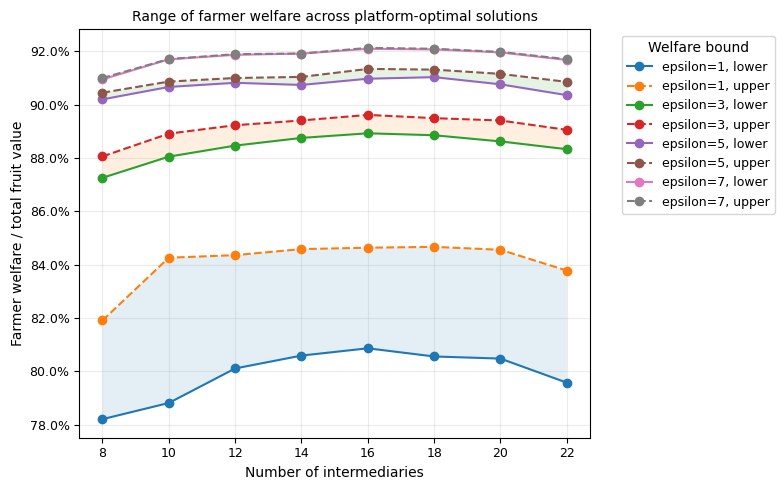

In [53]:
plot_welfare_range(
    df_gaps,
    lower_col="min_welfare_farmers",
    upper_col="max_welfare_farmers",
    ylabel="Farmer welfare / total fruit value",
    title="Range of farmer welfare across platform-optimal solutions"
)

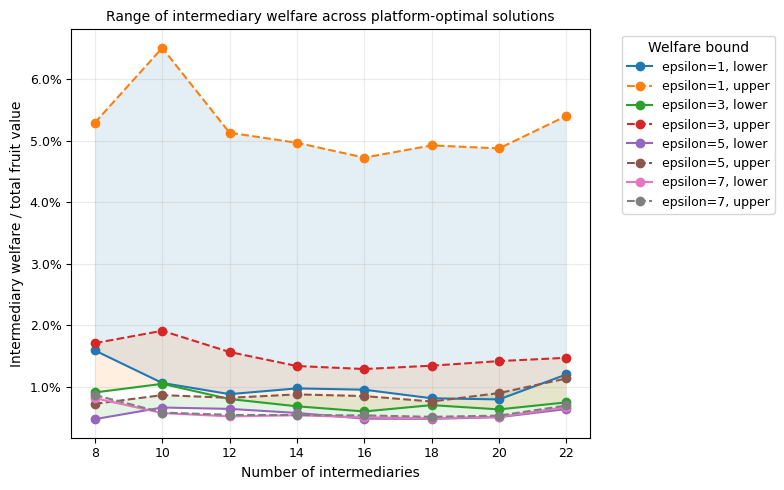

In [54]:
plot_welfare_range(
    df_gaps,
    lower_col="min_welfare_intermediaries",
    upper_col="max_welfare_intermediaries",
    ylabel="Intermediary welfare / total fruit value",
    title="Range of intermediary welfare across platform-optimal solutions"
)

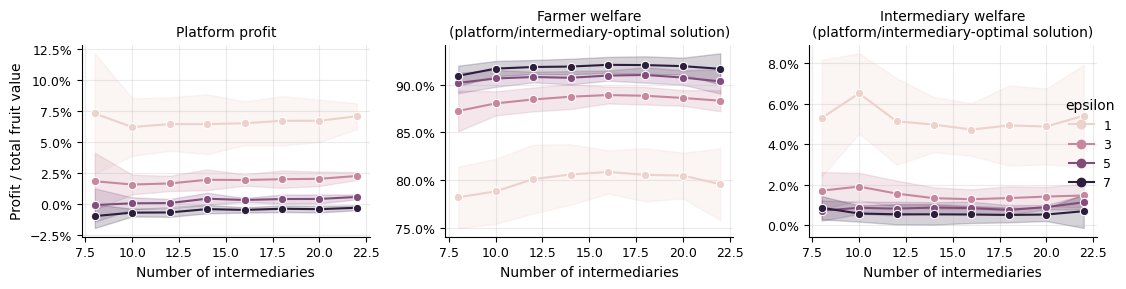

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter

df_gaps["avg_epsilon"] = df_gaps["avg_epsilon"].astype(int)
df_gaps["n_intermediaries"] = df_gaps["n_intermediaries"].astype(int)

metric_cols = {
    "Platform profit": "profit_percentage",
    "Farmer welfare\n(platform/intermediary-optimal solution)": "min_welfare_farmers",
    "Intermediary welfare\n(platform/intermediary-optimal solution)": "max_welfare_intermediaries",
}

long_df = df_gaps.melt(
    id_vars=["avg_epsilon", "instance", "n_intermediaries"],
    value_vars=list(metric_cols.values()),
    var_name="metric",
    value_name="value",
)

long_df["metric"] = long_df["metric"].map({v: k for k, v in metric_cols.items()})

g = sns.relplot(
    data=long_df,
    x="n_intermediaries",
    y="value",
    hue="avg_epsilon",
    col="metric",
    kind="line",
    estimator="mean",
    errorbar="sd",
    marker="o",
    facet_kws={"sharey": False, "sharex": True},
    height=3.0,
    aspect=1.15,
)

g.set_axis_labels("Number of intermediaries", "Profit / total fruit value")
g.set_titles("{col_name}")

for ax in g.axes.flat:
    ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))
    ax.grid(True, alpha=0.25)

g._legend.set_title("epsilon")
plt.tight_layout()
plt.show()

In [39]:
def plot_quadratic_average_trends(df):
    df_plot = df.copy()
    df_plot["avg_epsilon"] = df_plot["avg_epsilon"].astype(int)
    df_plot["n_intermediaries"] = df_plot["n_intermediaries"].astype(int)

    metric_cols = {
        "Farmer welfare": "min_welfare_farmers",
        "Intermediary welfare": "max_welfare_intermediaries",
    }

    for metric_label, metric_col in metric_cols.items():
        mean_df = (
            df_plot
            .groupby(["avg_epsilon", "n_intermediaries"], as_index=False)[metric_col]
            .mean()
        )

        sns.lmplot(
            data=mean_df,
            x="n_intermediaries",
            y=metric_col,
            hue="avg_epsilon",
            order=2,
            ci=None,
            height=4,
            aspect=1.4,
            scatter_kws={"s": 45},
            line_kws={"linewidth": 1.8},
        )

        plt.gca().yaxis.set_major_formatter(PercentFormatter(xmax=1))
        plt.xlabel("Number of intermediaries")
        plt.ylabel(f"{metric_label} / total fruit value")
        plt.title(f"Quadratic trend in average {metric_label}")
        plt.grid(True, alpha=0.25)
        plt.tight_layout()
        plt.show()

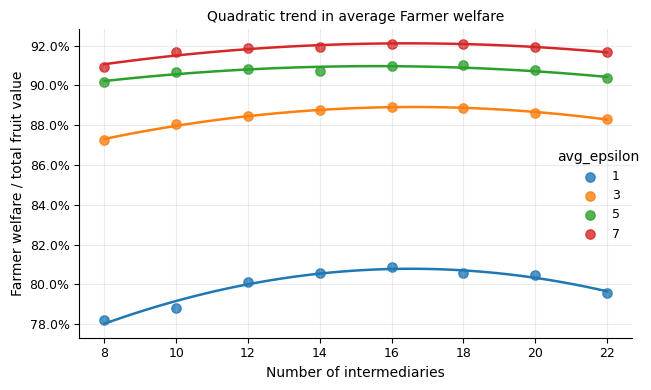

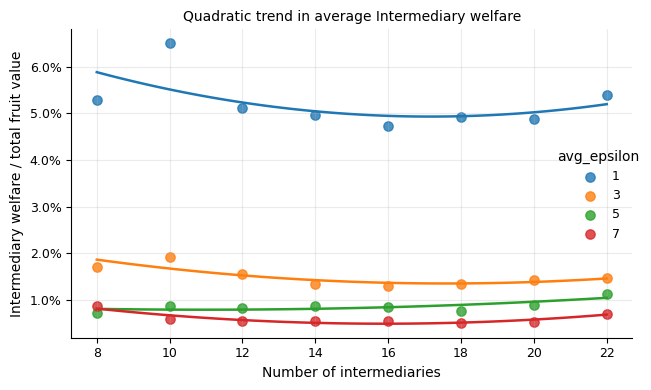

In [40]:
plot_quadratic_average_trends(df_gaps)

In [41]:
import numpy as np
import pandas as pd

def quadratic_coefficients_on_means(df, metric_col):
    rows = []

    for eps, group in df.groupby("avg_epsilon"):
        mean_df = (
            group
            .groupby("n_intermediaries", as_index=False)[metric_col]
            .mean()
            .sort_values("n_intermediaries")
        )

        x = mean_df["n_intermediaries"].to_numpy()
        y = mean_df[metric_col].to_numpy()

        # Center x for numerical stability
        x_centered = x - x.mean()

        coef = np.polyfit(x_centered, y, deg=2)

        rows.append({
            "epsilon": eps,
            "metric": metric_col,
            "quadratic_coef": coef[0],
            "linear_coef": coef[1],
            "intercept": coef[2],
        })

    return pd.DataFrame(rows)

In [42]:
farmer_quad = quadratic_coefficients_on_means(df_gaps, "min_welfare_farmers")
intermediary_quad = quadratic_coefficients_on_means(df_gaps, "max_welfare_intermediaries")

pd.concat([farmer_quad, intermediary_quad])

,epsilon,metric,quadratic_coef,linear_coef,intercept
0,1,min_welfare_farmers,-0.000380,0.001162,0.806948
1,3,min_welfare_farmers,-0.000217,0.000697,0.888619
2,5,min_welfare_farmers,-0.000131,0.000147,0.909682
3,7,min_welfare_farmers,-0.000147,0.000428,0.920874
0,1,max_welfare_intermediaries,0.000114,-0.000491,0.049860
1,3,max_welfare_intermediaries,0.000056,-0.000289,0.013847
2,5,max_welfare_intermediaries,0.000021,0.000169,0.008182
3,7,max_welfare_intermediaries,0.000052,-0.000092,0.004870


In [43]:
quad_results = pd.concat([farmer_quad, intermediary_quad], ignore_index=True)

mean_n = df_gaps["n_intermediaries"].mean()

quad_results["turning_point_n_intermediaries"] = (
    -quad_results["linear_coef"] / (2 * quad_results["quadratic_coef"])
    + mean_n
)

quad_results[
    [
        "epsilon",
        "metric",
        "quadratic_coef",
        "linear_coef",
        "turning_point_n_intermediaries",
    ]
]

,epsilon,metric,quadratic_coef,linear_coef,turning_point_n_intermediaries
0,1,min_welfare_farmers,-0.000380,0.001162,16.531209
1,3,min_welfare_farmers,-0.000217,0.000697,16.607235
2,5,min_welfare_farmers,-0.000131,0.000147,15.561768
3,7,min_welfare_farmers,-0.000147,0.000428,16.458510
4,1,max_welfare_intermediaries,0.000114,-0.000491,17.159888
5,3,max_welfare_intermediaries,0.000056,-0.000289,17.593921
6,5,max_welfare_intermediaries,0.000021,0.000169,10.945588
7,7,max_welfare_intermediaries,0.000052,-0.000092,15.879246


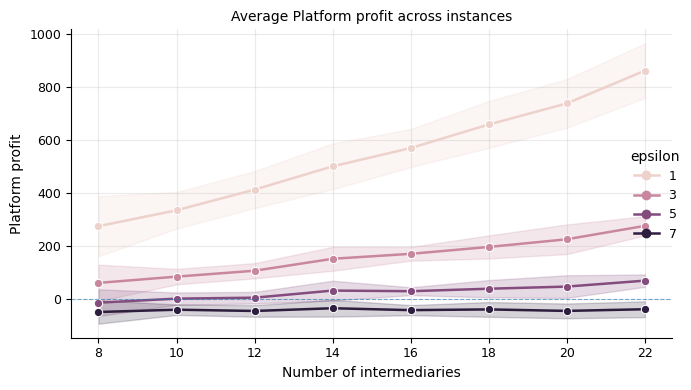

In [31]:
def plot_metric_averaged_across_instances_raw(df, metric_col, metric_label):
    df_plot = df.copy()
    df_plot["avg_epsilon"] = df_plot["avg_epsilon"].astype(int)
    df_plot["instance"] = df_plot["instance"].astype(int)
    df_plot["n_intermediaries"] = df_plot["n_intermediaries"].astype(int)

    g = sns.relplot(
        data=df_plot,
        x="n_intermediaries",
        y=metric_col,
        hue="avg_epsilon",
        kind="line",
        marker="o",
        estimator="mean",   # average across instances
        errorbar="sd",      # show std dev across instances
        sort=True,
        height=4,
        aspect=1.5,
        linewidth=1.8,
    )

    g.set_axis_labels("Number of intermediaries", metric_label)

    ax = g.ax
    ax.grid(True, alpha=0.25)
    ax.axhline(0, linestyle="--", linewidth=0.8, alpha=0.6)

    if g._legend is not None:
        g._legend.set_title("epsilon")

    plt.title(f"Average {metric_label} across instances")
    plt.tight_layout()
    plt.show()

plot_metric_averaged_across_instances_raw(
    df_gaps,
    "vanilla_profit",
    "Platform profit"
)

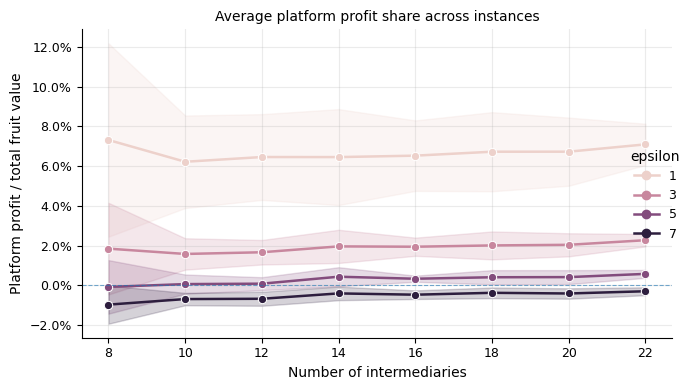

In [32]:
from matplotlib.ticker import PercentFormatter
import seaborn as sns
import matplotlib.pyplot as plt

def plot_profit_share_averaged_across_instances(df):
    df_plot = df.copy()
    df_plot["avg_epsilon"] = df_plot["avg_epsilon"].astype(int)
    df_plot["instance"] = df_plot["instance"].astype(int)
    df_plot["n_intermediaries"] = df_plot["n_intermediaries"].astype(int)

    g = sns.relplot(
        data=df_plot,
        x="n_intermediaries",
        y="profit_percentage",
        hue="avg_epsilon",
        kind="line",
        marker="o",
        estimator="mean",   # average across instances
        errorbar="sd",      # std dev across instances
        sort=True,
        height=4,
        aspect=1.5,
        linewidth=1.8,
    )

    g.set_axis_labels(
        "Number of intermediaries",
        "Platform profit / total fruit value"
    )

    ax = g.ax
    ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))
    ax.axhline(0, linestyle="--", linewidth=0.8, alpha=0.6)
    ax.grid(True, alpha=0.25)

    if g._legend is not None:
        g._legend.set_title("epsilon")

    plt.title("Average platform profit share across instances")
    plt.tight_layout()
    plt.show()

plot_profit_share_averaged_across_instances(df_gaps)

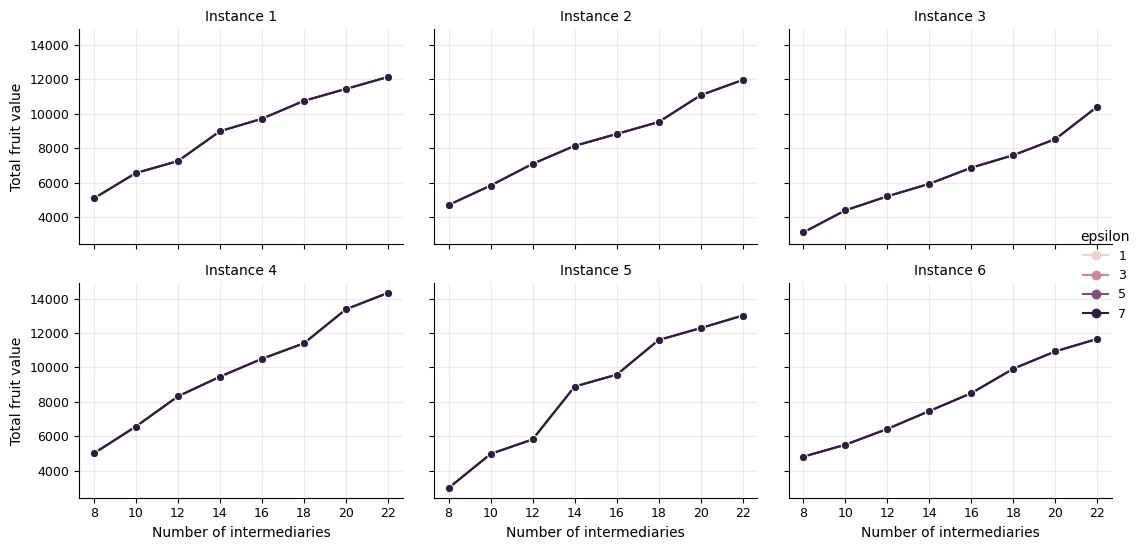

In [25]:
plot_metric_one_panel_per_instance_raw(
    df_gaps,
    "fruit_value",
    "Total fruit value"
)

In [56]:

actual_costs_platform = {0: 0.0775829869015126,
 1: 0.07768902868743288,
 2: 0.07792714074761442,
 3: 0.07779050019770295,
 4: 0.07780432119364723,
 5: 0.07780432119364725,
 6: 0.07758298690151258,
 7: 0.07758298690151257,
 8: 0.07758298690151258,
 9: 0.0775829869015126,
 }

actual_costs_improvement = {i: actual_costs_platform[i] - actual_costs_platform[0] for i in range(1, 10)}

actual_perc_platform = {0: 0.09959740695143612,
 1: 0.044517655245960054,
 2: 0.022845478696154217,
 3: 0.011845342163052535,
 4: 0.005042216382378989,
 5: 0.0009595428605521555,
 6: -0.002270061056467741,
 7: -0.004516052387438745,
 8: -0.005835568402234102,
 9: -0.007022154488203626}

actual_max_int = {0: 0.32758953661755996,
 1: 0.04175691614041955,
 2: 0.02060091126517644,
 3: 0.013039289559810586,
 4: 0.009350912870058112,
 5: 0.007924168304404811,
 6: 0.00772484422378011,
 7: 0.007443614889069343,
 8: 0.0063391957909994575,
 9: 0.005711990106601736}

actual_min_int = {0: 0.0,
 1: 0.01478574070810623,
 2: 0.007534357335050608,
 3: 0.007899933576455203,
 4: 0.005905858766726449,
 5: 0.006235383720283765,
 6: 0.0058198497457951585,
 7: 0.0073826381391337735,
 8: 0.006322061118747919,
 9: 0.00571137535532129}

actual_min_farmer = {0: 0.4952300812484759,
 1: 0.8360364116451723,
 2: 0.8786264810100395,
 3: 0.8973248797984186,
 4: 0.9078025612729003,
 5: 0.9133119793603803,
 6: 0.9169622416501595,
 7: 0.9194894623158415,
 8: 0.9219133974287067,
 9: 0.9237271891990739}

actual_max_farmer = {0: 0.8228196178660359,
 1: 0.8630075870774853,
 2: 0.8916930349401653,
 3: 0.9024642357817737,
 4: 0.911247615376232,
 5: 0.9150007639445015,
 6: 0.9188672361281446,
 7: 0.9195504390657769,
 8: 0.9219305321009583,
 9: 0.9237278039503545}



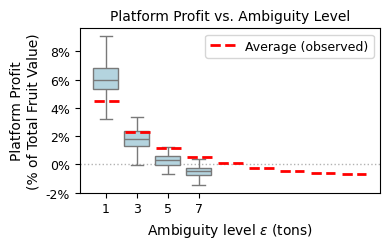

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

df_gaps = df_gaps.query("avg_epsilon >= 1.0")

plt.figure(figsize=(4, 2.6))

plt.rcParams.update({
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9
})

# Boxplot without outliers
ax = sns.boxplot(
    data=df_gaps, 
    x="avg_epsilon", 
    y="profit_percentage", 
    zorder=1, 
    showfliers=False,
    color="lightblue"
)

# Add horizontal reference line at 0% (lighter solid line)
plt.axhline(0, color="black", linestyle="dotted", linewidth=1, alpha=0.3, zorder=0)

# Overlay observed value per category with a dashed line
for i, category in enumerate(list(range(1, 10))):
    obs = actual_perc_platform.get(category, None)
    if obs is not None:
        plt.plot(
            [i - 0.38, i + 0.42], 
            [obs, obs], 
            color="red", 
            linewidth=2, 
            linestyle="--",  # Dashed line for the average
            label="Average (observed)" if i == 0 else "", 
            zorder=10
        )

# Format y-axis as percentages
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y * 100:.0f}%'))

# Clean and informative labels
plt.ylabel("Platform Profit\n(% of Total Fruit Value)")
plt.xlabel(r"Ambiguity level $\epsilon$ (tons)")
plt.title("Platform Profit vs. Ambiguity Level")

# Only show one legend entry for the observed line
handles, labels = ax.get_legend_handles_labels()
if handles:
    plt.legend(handles[:1], labels[:1], loc="upper right")

plt.tight_layout()
plt.savefig("../figures/platform_profit.pdf", bbox_inches='tight')
plt.show()

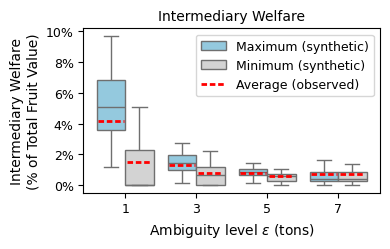

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

plt.rcParams.update({
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9
})

# Set color palette manually to ensure consistency
palette = {
    "Maximum (synthetic)": "skyblue", 
    "Minimum (synthetic)": "lightgray"
}

# Melt the dataframe
df_melted = df_gaps.melt(
    id_vars='avg_epsilon', 
    value_vars=['max_welfare_intermediaries', 'min_welfare_intermediaries'], 
    var_name='Welfare Type', 
    value_name='Welfare'
)

# Improve category names for legend
df_melted['Welfare Type'] = df_melted['Welfare Type'].map({
    'max_welfare_intermediaries': 'Maximum (synthetic)', 
    'min_welfare_intermediaries': 'Minimum (synthetic)'
})

# Create boxplot
plt.figure(figsize=(4, 2.6))
ax = sns.boxplot(
    data=df_melted, 
    x="avg_epsilon", 
    y="Welfare", 
    hue="Welfare Type", 
    palette=palette, 
    showfliers=False
)

# Overlay actual data lines with red dashed lines for averages
for i, category in enumerate(sorted(df_gaps["avg_epsilon"].unique())):
    obs_max = actual_max_int.get(category, None)
    obs_min = actual_min_int.get(category, None)
    if obs_max is not None:
        line, = plt.plot(
            [i - 0.38, i - 0.02], [obs_max, obs_max], 
            color="red", linewidth=2, linestyle="--", 
            label="Average (observed)" if i == 0 else "", zorder=10
        )
        line.set_dashes([2, 1])
    if obs_min is not None:
        line, = plt.plot(
            [i + 0.02, i + 0.38], [obs_min, obs_min], 
            color="red", linewidth=2, linestyle="--", 
            label=None, zorder=10
        )
        line.set_dashes([2, 1])

# Format y-axis
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y * 100:.0f}%'))

# Labeling
plt.ylabel("Intermediary Welfare\n(% of Total Fruit Value)")
plt.xlabel(r"Ambiguity level $\epsilon$ (tons)")
plt.title("Intermediary Welfare")

# Legend cleanup
handles, labels = ax.get_legend_handles_labels()
# Deduplicate legend and ensure all three entries are present
unique = dict(zip(labels, handles))
plt.legend(
    [unique["Maximum (synthetic)"], unique["Minimum (synthetic)"], unique["Average (observed)"]],
    ["Maximum (synthetic)", "Minimum (synthetic)", "Average (observed)"],
    title="", loc="upper right"
)

plt.tight_layout()
plt.savefig("../figures/intermediary_welfare.pdf", bbox_inches='tight')
plt.show()

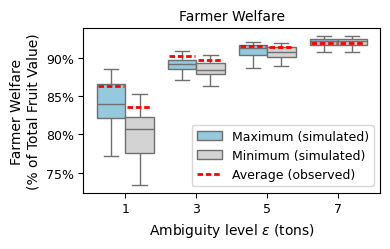

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

plt.rcParams.update({
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9
})

# Set color palette manually to ensure consistency
palette = {
    "Maximum (simulated)": "skyblue", 
    "Minimum (simulated)": "lightgray"
}

# Melt the dataframe
df_melted = df_gaps.melt(
    id_vars='avg_epsilon', 
    value_vars=['max_welfare_farmers', 'min_welfare_farmers'], 
    var_name='Welfare Type', 
    value_name='Welfare'
)

# Improve category names for legend
df_melted['Welfare Type'] = df_melted['Welfare Type'].map({
    'max_welfare_farmers': 'Maximum (simulated)', 
    'min_welfare_farmers': 'Minimum (simulated)'
})

# Create boxplot
plt.figure(figsize=(4, 2.6))  # Adjusted figsize
ax = sns.boxplot(
    data=df_melted, 
    x="avg_epsilon", 
    y="Welfare", 
    hue="Welfare Type", 
    palette=palette, 
    showfliers=False
)

# Overlay actual data lines with red dashed lines for averages
for i, category in enumerate(sorted(df_gaps["avg_epsilon"].unique())):
    obs_max = actual_max_farmer.get(category, None)
    obs_min = actual_min_farmer.get(category, None)
    if obs_max is not None:
        line, = plt.plot(
            [i - 0.38, i - 0.02], [obs_max, obs_max], 
            color="red", linewidth=2, linestyle="--", 
            label="Average (observed)" if i == 0 else "", zorder=10
        )
        line.set_dashes([2, 1])  # Custom dash pattern: short dash, small gap
    if obs_min is not None:
        line, = plt.plot(
            [i + 0.02, i + 0.38], [obs_min, obs_min], 
            color="red", linewidth=2, linestyle="--", 
            label=None, zorder=10
        )
        line.set_dashes([2, 1])  # Custom dash pattern: short dash, small gap

# Format y-axis
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y * 100:.0f}%'))

# Labeling
plt.ylabel("Farmer Welfare\n(% of Total Fruit Value)")
plt.xlabel(r"Ambiguity level $\epsilon$ (tons)")
plt.title("Farmer Welfare")

# Legend cleanup
handles, labels = ax.get_legend_handles_labels()
# Deduplicate legend and ensure all three entries are present
unique = dict(zip(labels, handles))
plt.legend(
    [unique["Maximum (simulated)"], unique["Minimum (simulated)"], unique["Average (observed)"]],
    ["Maximum (simulated)", "Minimum (simulated)", "Average (observed)"],
    title="", loc="lower right"
)

plt.tight_layout()
plt.savefig("../figures/farmer_welfare.pdf", bbox_inches='tight')
plt.show()

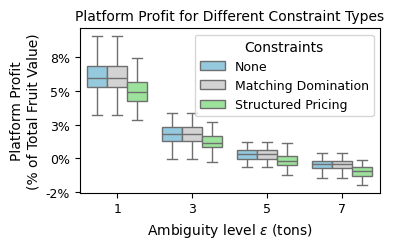

In [60]:
import seaborn as sns
from matplotlib.ticker import FuncFormatter

import matplotlib.pyplot as plt

# Melt the dataframe for easier plotting
profit_data = df_gaps.melt(
    id_vars='avg_epsilon', 
    value_vars=['vanilla_profit_by_fruit_value', 'domination_profit_by_fruit_value', 'structured_profit_by_fruit_value'], 
    var_name='Constraints', 
    value_name='Profit'
)

plt.rcParams.update({
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9
})

# Set color palette manually for consistency
palette = {
    "None": "skyblue", 
    "Matching Domination": "lightgray", 
    "Structured Pricing": "lightgreen"
}

# Improve category names for legend
profit_data['Constraints'] = profit_data['Constraints'].map({
    'vanilla_profit_by_fruit_value': 'None', 
    'domination_profit_by_fruit_value': 'Matching Domination', 
    'structured_profit_by_fruit_value': 'Structured Pricing'
})

# Create the boxplot
plt.figure(figsize=(4, 2.6))
ax = sns.boxplot(
    data=profit_data, 
    x="avg_epsilon", 
    y="Profit", 
    hue="Constraints", 
    palette=palette, 
    showfliers=False
)

# Format y-axis
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y:.2f}'))

# Labeling
plt.ylabel("Platform Profit\n(% of Total Fruit Value)")
plt.xlabel(r"Ambiguity level $\epsilon$ (tons)")
plt.title("Platform Profit for Different Constraint Types")
# Format y-axis as percentages
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y * 100:.0f}%'))

# Adjust legend
handles, labels = ax.get_legend_handles_labels()
plt.legend(handles, labels, title="Constraints", loc="upper right")

plt.tight_layout()
plt.savefig("../figures/profit_by_contraint.pdf", bbox_inches='tight')
plt.show()